**An Intelligent Brain MRI Classification System Using CNN and Transfer Learning**

The significance of this project lies in comparing two important approaches to deep-learning-based image classification. First, a CNN is developed from scratch to establish a baseline and provide an understanding of how convolutional layers, pooling, activation functions and dense layers learn visual representations from MRI images. After establishing the baseline, transfer learning is introduced using the EfficientNetB0 architecture. This allows the project to investigate whether visual features learned from a large pre-existing dataset can be transferred to the brain MRI classification task.
Developer : Engr Mehshar

Step 1: Add Data Set from Kaggle and Import Libraries

In [7]:
import kagglehub
path = kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset")
print(path)

Using Colab cache for faster access to the 'brain-tumor-mri-dataset' dataset.
/kaggle/input/brain-tumor-mri-dataset


In [8]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

Step 2: Data Preprocessing

Training Set Preprocessing

In [ ]:
train_datagen = ImageDataGenerator(
    rescale = 1/255,
    shear_range = 0.2,
    zoom_range = 0.2,
    horizontal_flip = True)

train_dataset = train_datagen.flow_from_directory(
    '/content/brain-tumor-mri-dataset/brain-tumor-mri-dataset/Training',
    target_size = (64, 64),
    batch_size = 32,
    class_mode = 'categorical' # Changed from 'binary' to 'categorical'
)

Found 5712 images belonging to 4 classes.


Test Set Preprocessing

In [ ]:
test_datagen = ImageDataGenerator(rescale = 1./255)
test_set = test_datagen.flow_from_directory('/content/brain-tumor-mri-dataset/brain-tumor-mri-dataset/Testing',
                                            target_size = (64, 64),
                                            batch_size = 32,
                                            class_mode = 'categorical' # Changed from 'binary' to 'categorical'
)

Found 1311 images belonging to 4 classes.


Step 3: Building CNN Architecture

In [ ]:
#Initialize CNN
cnn = tf.keras.models.Sequential()

In [ ]:
#Perform Convolution
cnn.add(tf.keras.layers.Conv2D(filters = 32, kernel_size = 3, padding='same', input_shape = [64, 64, 3]))
cnn.add(tf.keras.layers.BatchNormalization())
cnn.add(tf.keras.layers.Activation('relu'))


In [ ]:
#Perform Pooling
cnn.add(tf.keras.layers.MaxPool2D(pool_size = 2, strides = 2))

In [ ]:
#Add Second Convolution
cnn.add(tf.keras.layers.Conv2D(filters = 32, kernel_size = 3, padding='same')) # Added padding
cnn.add(tf.keras.layers.BatchNormalization())
cnn.add(tf.keras.layers.Activation('relu'))
cnn.add(tf.keras.layers.MaxPool2D(pool_size = 2, strides = 2))


In [ ]:
#Flattening
cnn.add(tf.keras.layers.Flatten())

In [ ]:
#Full Connection
cnn.add(tf.keras.layers.Dense(units = 128))
cnn.add(tf.keras.layers.BatchNormalization())
cnn.add(tf.keras.layers.Activation('relu'))


In [ ]:
#Output layer
# Changed to output logits for numerical stability with from_logits=True in loss function
cnn.add(tf.keras.layers.Dense(units = 4))

Step 4: Training CNN

In [ ]:
#Compiling CNN
# Using CategoricalCrossentropy with from_logits=True for numerical stability
cnn.compile(optimizer = 'adam', loss = tf.keras.losses.CategoricalCrossentropy(from_logits=True), metrics = ['accuracy'])

In [ ]:
#Training the CNN on Training set and evaluating Model Performance on Test set
cnn.fit(x = train_dataset, validation_data = test_set, epochs = 25)

Epoch 1/25
179/179 ━━━━━━━━━━━━━━━━━━━━ 39s 157ms/step - accuracy: 0.7432 - loss: 0.6580 - val_accuracy: 0.4630 - val_loss: 1.2086
Epoch 2/25
179/179 ━━━━━━━━━━━━━━━━━━━━ 22s 123ms/step - accuracy: 0.8304 - loss: 0.4364 - val_accuracy: 0.6377 - val_loss: 0.9366
Epoch 3/25
179/179 ━━━━━━━━━━━━━━━━━━━━ 21s 118ms/step - accuracy: 0.8654 - loss: 0.3571 - val_accuracy: 0.6461 - val_loss: 0.8446
Epoch 4/25
179/179 ━━━━━━━━━━━━━━━━━━━━ 21s 118ms/step - accuracy: 0.8950 - loss: 0.2806 - val_accuracy: 0.8024 - val_loss: 0.5713
Epoch 5/25
179/179 ━━━━━━━━━━━━━━━━━━━━ 22s 120ms/step - accuracy: 0.9093 - loss: 0.2508 - val_accuracy: 0.6629 - val_loss: 1.2379
Epoch 6/25
179/179 ━━━━━━━━━━━━━━━━━━━━ 20s 113ms/step - accuracy: 0.9214 - loss: 0.2210 - val_accuracy: 0.8200 - val_loss: 0.5160
Epoch 7/25
179/179 ━━━━━━━━━━━━━━━━━━━━ 21s 119ms/step - accuracy: 0.9310 - loss: 0.1909 - val_accuracy: 0.7536 - val_loss: 0.7945
Epoch 8/25
179/179 ━━━━━━━━━━━━━━━━━━━━ 20s 113ms/step - accuracy: 0.9375 - loss: 0

Step 5- Import Libraries for Transfer Learning

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


Step 6 - Setting Dataset Path Correctly

In [ ]:
import kagglehub
path = kagglehub.dataset_download(
    "masoudnickparvar/brain-tumor-mri-dataset"
)

Using Colab cache for faster access to the 'brain-tumor-mri-dataset' dataset.


In [ ]:
DATASET_PATH = "/kaggle/input/brain-tumor-mri-dataset"

TRAIN_PATH = os.path.join(DATASET_PATH, "Training")
TEST_PATH = os.path.join(DATASET_PATH, "Testing")

print("Training path:", TRAIN_PATH)
print("Testing path:", TEST_PATH)

print("Training classes:", os.listdir(TRAIN_PATH))
print("Testing classes:", os.listdir(TEST_PATH))

Training path: /kaggle/input/brain-tumor-mri-dataset/Training
Testing path: /kaggle/input/brain-tumor-mri-dataset/Testing
Training classes: ['pituitary', 'notumor', 'meningioma', 'glioma']
Testing classes: ['pituitary', 'notumor', 'meningioma', 'glioma']


Step 7 - Create Data Generator (224 x 224)

In [ ]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

In [ ]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    width_shift_range=0.10,
    height_shift_range=0.10,
    zoom_range=0.15,
    horizontal_flip=True,
    fill_mode="nearest"
)

test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

In [ ]:
train_dataset = train_datagen.flow_from_directory(
    TRAIN_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True
)

test_dataset = test_datagen.flow_from_directory(
    TEST_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

Found 5600 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.


In [ ]:
class_names = list(train_dataset.class_indices.keys())

print("Class names:")
print(class_names)

print("Class indices:")
print(train_dataset.class_indices)

Class names:
['glioma', 'meningioma', 'notumor', 'pituitary']
Class indices:
{'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


Step 8 - Build Transfer Learning Model

In [5]:
from tensorflow.keras.applications import EfficientNetB0

base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

In [10]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model

# Define class_names explicitly for this cell to resolve NameError
class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']

# Re-defining base_model to resolve NameError in this cell
base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

x = base_model.output

x = GlobalAveragePooling2D()(x)

x = Dense(256, activation="relu")(x)

x = Dropout(0.4)(x)

output = Dense(
    len(class_names),
    activation="softmax"
)(x)

transfer_model = Model(
    inputs=base_model.input,
    outputs=output
)

Step 9  Compile the Model

In [12]:
transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [13]:
transfer_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_12        │ (None, 224, 224,  │          0 │ input_layer_6[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_6     │ (None, 224, 224,  │          7 │ rescaling_12[0][… │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_13        │ (None, 224, 224,  │          0 │ normalization_6[… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_13[0][… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,378,535 (16.70 MB)

 Trainable params: 328,964 (1.25 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

Step 10 - Train the Transfer Learning Model

In [17]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

callbacks = [

    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        min_lr=1e-7
    ),

    ModelCheckpoint(
        "best_brain_tumor_transfer_learning.keras",
        monitor="val_accuracy",
        save_best_only=True
    )
]

In [19]:
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.efficientnet import preprocess_input

DATASET_PATH = "/kaggle/input/brain-tumor-mri-dataset"

TRAIN_PATH = os.path.join(DATASET_PATH, "Training")
TEST_PATH = os.path.join(DATASET_PATH, "Testing")

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    width_shift_range=0.10,
    height_shift_range=0.10,
    zoom_range=0.15,
    horizontal_flip=True,
    fill_mode="nearest"
)

test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_dataset = train_datagen.flow_from_directory(
    TRAIN_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True
)

test_dataset = test_datagen.flow_from_directory(
    TEST_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

history = transfer_model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=15,
    callbacks=callbacks
)

Found 5600 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.
Epoch 1/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 150s 699ms/step - accuracy: 0.6900 - loss: 0.8081 - val_accuracy: 0.7344 - val_loss: 0.6706 - learning_rate: 1.0000e-04
Epoch 2/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 80s 458ms/step - accuracy: 0.8143 - loss: 0.5003 - val_accuracy: 0.7856 - val_loss: 0.5852 - learning_rate: 1.0000e-04
Epoch 3/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 82s 466ms/step - accuracy: 0.8371 - loss: 0.4325 - val_accuracy: 0.7931 - val_loss: 0.5873 - learning_rate: 1.0000e-04
Epoch 4/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 81s 463ms/step - accuracy: 0.8505 - loss: 0.3986 - val_accuracy: 0.8112 - val_loss: 0.5439 - learning_rate: 1.0000e-04
Epoch 5/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 81s 460ms/step - accuracy: 0.8575 - loss: 0.3838 - val_accuracy: 0.8169 - val_loss: 0.5237 - learning_rate: 1.0000e-04
Epoch 6/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 81s 463ms/step - accuracy: 0.8689 - loss: 0.3479 - val_accuracy: 0.8331 - val_lo

Step 11 - Evaluate the transfer learning model

In [20]:
test_loss, test_accuracy = transfer_model.evaluate(test_dataset)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 103ms/step - accuracy: 0.8331 - loss: 0.4851
Test Loss: 0.4851103127002716
Test Accuracy: 0.8331249952316284


Step 12 - Plot the training accuracy

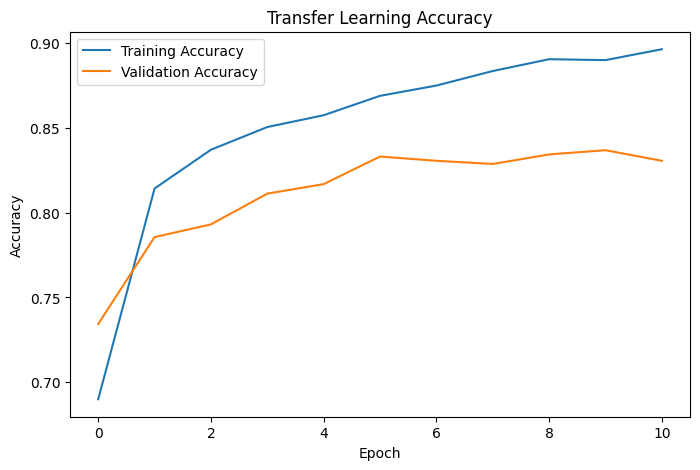

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Transfer Learning Accuracy")

plt.legend()
plt.show()

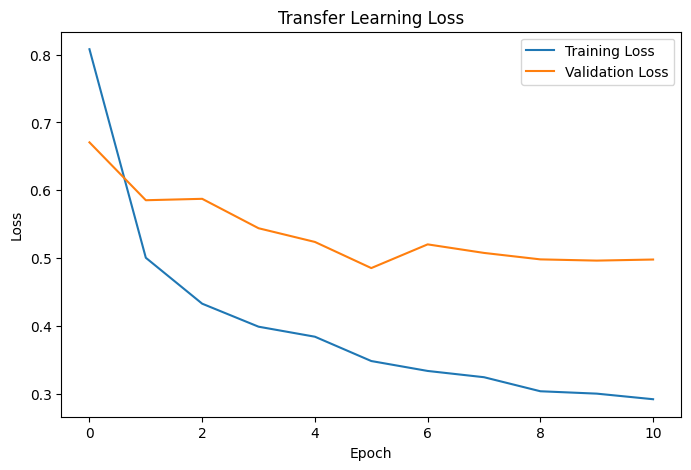

In [23]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Transfer Learning Loss")

plt.legend()
plt.show()

Step 13 - Perform Fine Tunning

In [25]:
base_model.trainable = False

In [27]:
base_model.trainable = True

In [29]:
for layer in base_model.layers[:-30]:
    layer.trainable = False

In [31]:
transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-5
    ),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [32]:
fine_tune_history = transfer_model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=10,
    callbacks=callbacks
)

Epoch 1/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 115s 500ms/step - accuracy: 0.7979 - loss: 0.5961 - val_accuracy: 0.8106 - val_loss: 0.5411 - learning_rate: 1.0000e-05
Epoch 2/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 79s 452ms/step - accuracy: 0.8423 - loss: 0.4664 - val_accuracy: 0.8081 - val_loss: 0.5487 - learning_rate: 1.0000e-05
Epoch 3/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 81s 465ms/step - accuracy: 0.8546 - loss: 0.4259 - val_accuracy: 0.8062 - val_loss: 0.5515 - learning_rate: 2.0000e-06
Epoch 4/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 81s 461ms/step - accuracy: 0.8596 - loss: 0.4161 - val_accuracy: 0.8081 - val_loss: 0.5475 - learning_rate: 2.0000e-06
Epoch 5/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 80s 455ms/step - accuracy: 0.8605 - loss: 0.4082 - val_accuracy: 0.8069 - val_loss: 0.5467 - learning_rate: 4.0000e-07


Step 14 - Uploading MRI Image and Get prediction

In [34]:
import ipywidgets as widgets
from IPython.display import display

In [50]:
upload = widgets.FileUpload(
    accept="image/*",
    multiple=False
)

display(upload)

FileUpload(value={}, accept='image/*', description='Upload')

Step 15- Prediction Function

In [51]:
from PIL import Image
import io

In [52]:
def predict_uploaded_image(upload_widget):

    if len(upload_widget.value) == 0:
        print("Please upload an MRI image.")
        return

    uploaded_file = list(upload_widget.value.values())[0]

    image_data = uploaded_file["content"]

    image = Image.open(io.BytesIO(image_data)).convert("RGB")

    # Display uploaded image
    plt.figure(figsize=(6, 6))
    plt.imshow(image)
    plt.axis("off")
    plt.title("Uploaded MRI Image")
    plt.show()

    # Resize
    image_resized = image.resize(IMG_SIZE)

    # Convert to array
    image_array = np.array(image_resized)

    # Add batch dimension
    image_array = np.expand_dims(image_array, axis=0)

    # Preprocess
    image_array = preprocess_input(image_array)

    # Prediction
    predictions = transfer_model.predict(image_array)

    predicted_index = np.argmax(predictions[0])

    predicted_class = class_names[predicted_index]

    confidence = predictions[0][predicted_index] * 100

    print("--------------------------------")
    print("Brain Tumor Prediction")
    print("--------------------------------")
    print("Predicted Class:", predicted_class)
    print(f"Confidence: {confidence:.2f}%")

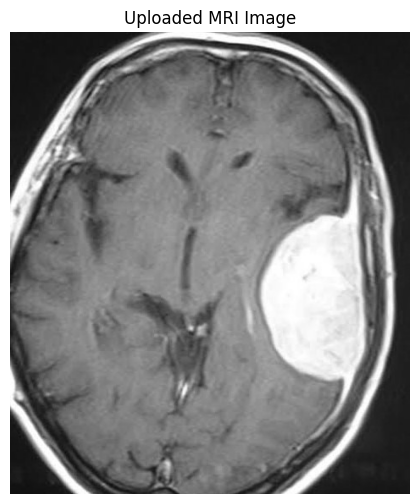

1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step
--------------------------------
Brain Tumor Prediction
--------------------------------
Predicted Class: meningioma
Confidence: 41.61%


In [54]:
import numpy as np
predict_uploaded_image(upload)

Step 16 - Make the output better

In [57]:
def predict_uploaded_image(upload_widget):

    if len(upload_widget.value) == 0:
        print("Please upload an MRI image.")
        return

    uploaded_file = list(upload_widget.value.values())[0]

    image_data = uploaded_file["content"]

    image = Image.open(
        io.BytesIO(image_data)
    ).convert("RGB")

    # Display image
    plt.figure(figsize=(6, 6))
    plt.imshow(image)
    plt.axis("off")
    plt.title("Uploaded MRI Image")
    plt.show()

    # Resize
    image_resized = image.resize(IMG_SIZE)

    # Convert image to array
    image_array = np.array(image_resized)

    # Add batch dimension
    image_array = np.expand_dims(image_array, axis=0)

    # Preprocess
    image_array = preprocess_input(image_array)

    # Predict
    predictions = transfer_model.predict(image_array)[0]

    predicted_index = np.argmax(predictions)

    predicted_class = class_names[predicted_index]

    confidence = predictions[predicted_index] * 100

    print("\n==============================")
    print("      BRAIN TUMOR RESULT")
    print("==============================")

    print("Predicted Class :", predicted_class)
    print(f"Confidence      : {confidence:.2f}%")

    print("\nClass Probabilities:")

    for class_name, probability in zip(
        class_names,
        predictions
    ):
        print(
            f"{class_name:<15} : "
            f"{probability * 100:.2f}%"
        )

    # Probability graph
    plt.figure(figsize=(8, 5))

    plt.bar(
        class_names,
        predictions * 100
    )

    plt.ylabel("Probability (%)")
    plt.xlabel("Tumor Class")
    plt.title("Brain Tumor Prediction Probabilities")

    plt.ylim(0, 100)

    plt.show()

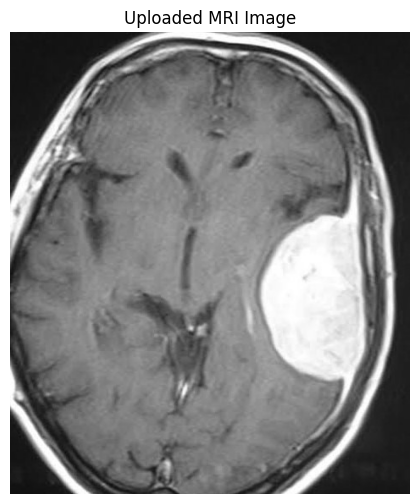

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step

      BRAIN TUMOR RESULT
Predicted Class : meningioma
Confidence      : 41.61%

Class Probabilities:
glioma          : 8.86%
meningioma      : 41.61%
notumor         : 28.26%
pituitary       : 21.27%


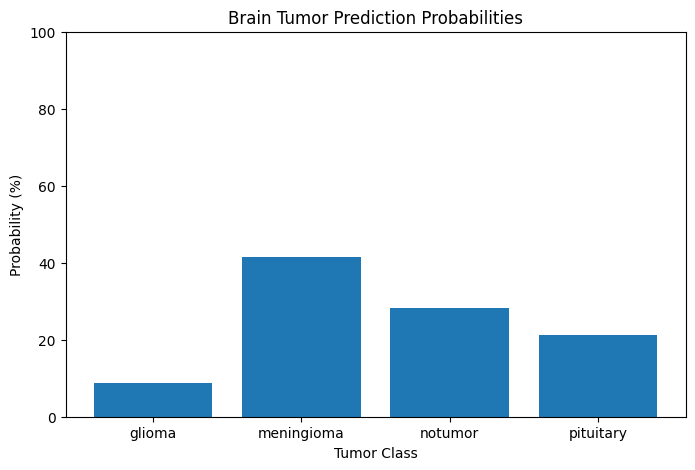

In [58]:
predict_uploaded_image(upload)

Step 17 - More Improvement - Confusion Matrix

50/50 ━━━━━━━━━━━━━━━━━━━━ 14s 96ms/step


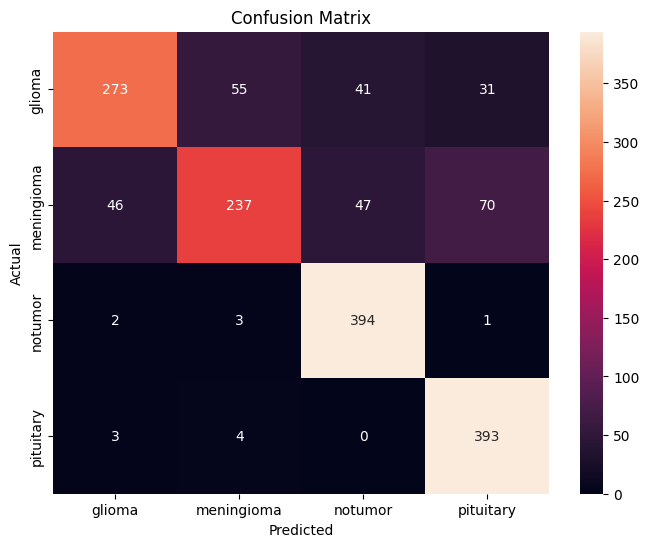

In [59]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

test_dataset.reset()

predictions = transfer_model.predict(test_dataset)

predicted_classes = np.argmax(
    predictions,
    axis=1
)

true_classes = test_dataset.classes

cm = confusion_matrix(
    true_classes,
    predicted_classes
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [60]:
print(
    classification_report(
        true_classes,
        predicted_classes,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

      glioma       0.84      0.68      0.75       400
  meningioma       0.79      0.59      0.68       400
     notumor       0.82      0.98      0.89       400
   pituitary       0.79      0.98      0.88       400

    accuracy                           0.81      1600
   macro avg       0.81      0.81      0.80      1600
weighted avg       0.81      0.81      0.80      1600

